# Балансировка Silver Dataset

## Проблема

Silver dataset содержит ~1.26M пар, из которых **99.4% имеют score=0**. Обучение bi-encoder на таких данных бесполезно — модель выучит только предсказывать "не похоже".

## Связь со статьёй

Эта проблема описана в статье Augmented SBERT (Thakur et al., 2021):

> "With random sampling, we observe an extremely high number of low similarity pairs. This is expected, as randomly sampling two sentences yields in nearly all cases a dissimilar pair." (Section 6.1)

> "Random sampling (R.S.) **decreases performance** compared to training SBERT without any additional silver data in most cases." (Section 6.1)

Авторы показали (Figure 4), что распределение score в silver dataset критически влияет на результат. Стратегии BM25 и KDE, дающие более сбалансированное распределение, приводили к лучшим результатам (Table 5).

В нашем случае silver dataset размечался cross-encoder-ом, который для подавляющего большинства случайных пар (описание товара + нерелевантный пост) выдаёт score ≈ 0. Это эквивалентно Random Sampling из статьи.

## Решение

Применяем downsampling негативов по принципу KDE-стратегии из статьи:
- Сохраняем **все** пары с score > 0 (информативные примеры)
- Сэмплируем негативные пары (score = 0) в заданном соотношении к позитивным

Результирующий dataset попадает в диапазон эффективных silver dataset-ов из статьи (Table 11: 3,964 — 50,147 пар для лучших стратегий).

In [24]:
# ============================================================
# Конфигурация
# ============================================================

SILVER_DATA_GLOB = "data/silver/silver_pairs_part_*.csv"
OUTPUT_PARQUET = "data/silver/silver_balanced.parquet"

# Golden data — для объединения с silver (Augmented SBERT, Section 3.1)
GOLDEN_DATA = "data/golden/golden_pairs.csv"
GOLD_TEST_SIZE = 0.2                                    # 20% gold → eval, 80% → train
GOLD_SEED = 42

# Итоговые файлы
OUTPUT_TRAIN_MERGED = "data/silver/train_gold_silver.parquet"  # gold_train + silver_balanced
OUTPUT_GOLD_EVAL = "data/golden/golden_eval.parquet"           # gold_eval (для оценки bi-encoder)

# Соотношение негативных к позитивным парам
# 1:3 — на каждую позитивную пару берём 3 негативных
NEG_RATIO = 3

SEED = 42

## 1. Загрузка и анализ исходного silver dataset

In [25]:
import os
from glob import glob
from datasets import load_dataset
import numpy as np

csv_files = sorted(glob(SILVER_DATA_GLOB))
print(f"CSV-файлов: {len(csv_files)}")

dataset = load_dataset(
    "csv",
    data_files=csv_files,
    delimiter="\t",
    encoding="utf-8-sig",
    split="train",
)

# Оставляем только нужные колонки
cols_to_remove = [c for c in dataset.column_names if c not in ["product_desc", "post_text", "score"]]
dataset = dataset.remove_columns(cols_to_remove)

# score к float
if isinstance(dataset[0]["score"], str):
    dataset = dataset.map(lambda x: {"score": float(x["score"])})

scores = np.array(dataset["score"])

print(f"\nВсего пар: {len(scores):,}")
print(f"Mean: {scores.mean():.4f}, Median: {np.median(scores):.4f}")
print(f"Score = 0: {(scores == 0).sum():,} ({(scores == 0).mean()*100:.1f}%)")
print(f"Score > 0: {(scores > 0).sum():,} ({(scores > 0).mean()*100:.1f}%)")
print(f"Score > 0.5: {(scores > 0.5).sum():,} ({(scores > 0.5).mean()*100:.1f}%)")

CSV-файлов: 126


Resolving data files:   0%|          | 0/126 [00:00<?, ?it/s]


Всего пар: 1,260,000
Mean: 0.0048, Median: 0.0000
Score = 0: 1,252,585 (99.4%)
Score > 0: 7,415 (0.6%)
Score > 0.5: 7,415 (0.6%)


## 2. Визуализация: до балансировки

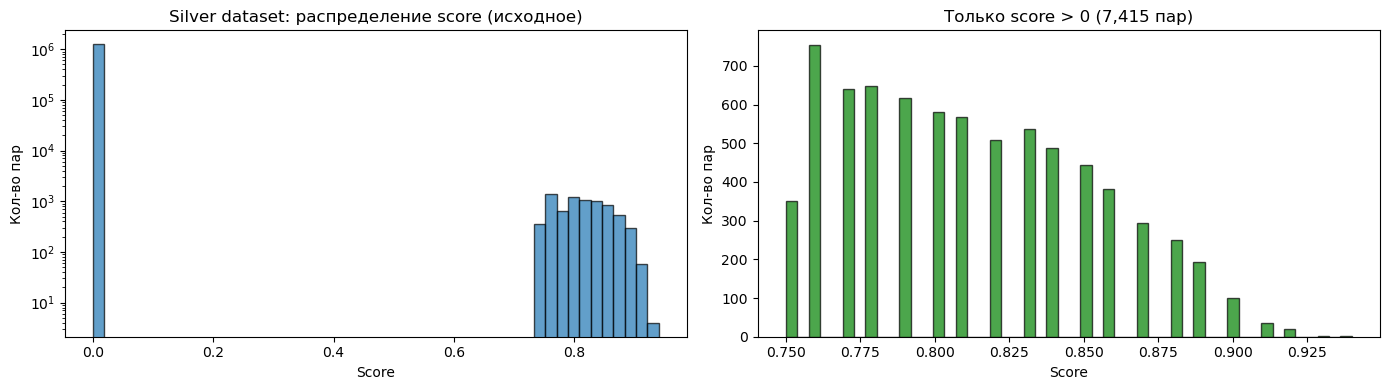

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Полное распределение
axes[0].hist(scores, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Кол-во пар")
axes[0].set_title("Silver dataset: распределение score (исходное)")
axes[0].set_yscale("log")

# Только ненулевые
nonzero = scores[scores > 0]
axes[1].hist(nonzero, bins=50, edgecolor="black", alpha=0.7, color="green")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Кол-во пар")
axes[1].set_title(f"Только score > 0 ({len(nonzero):,} пар)")

plt.tight_layout()
plt.show()

## 3. Балансировка

Стратегия:
- Все пары с score > 0 → **позитивные** (информативные примеры)
- Случайная выборка из пар с score = 0 → **негативные** (в соотношении NEG_RATIO к позитивным)
- Перемешиваем результат

In [27]:
from datasets import concatenate_datasets

# Разделяем на позитивные и негативные
positive = dataset.filter(lambda x: x["score"] > 0)
negative = dataset.filter(lambda x: x["score"] == 0)

n_pos = len(positive)
n_neg_sample = min(n_pos * NEG_RATIO, len(negative))

print(f"Позитивных пар (score > 0): {n_pos:,}")
print(f"Негативных пар (score = 0): {len(negative):,}")
print(f"Сэмплируем негативных: {n_neg_sample:,} (ratio 1:{NEG_RATIO})")

# Случайная выборка негативных
negative_sampled = negative.shuffle(seed=SEED).select(range(n_neg_sample))

# Объединяем и перемешиваем
balanced = concatenate_datasets([positive, negative_sampled])
balanced = balanced.shuffle(seed=SEED)

print(f"\nСбалансированный dataset: {len(balanced):,} пар")
print(f"  Позитивных: {n_pos:,} ({n_pos/len(balanced)*100:.1f}%)")
print(f"  Негативных: {n_neg_sample:,} ({n_neg_sample/len(balanced)*100:.1f}%)")

Позитивных пар (score > 0): 7,415
Негативных пар (score = 0): 1,252,585
Сэмплируем негативных: 22,245 (ratio 1:3)

Сбалансированный dataset: 29,660 пар
  Позитивных: 7,415 (25.0%)
  Негативных: 22,245 (75.0%)


## 4. Визуализация: после балансировки

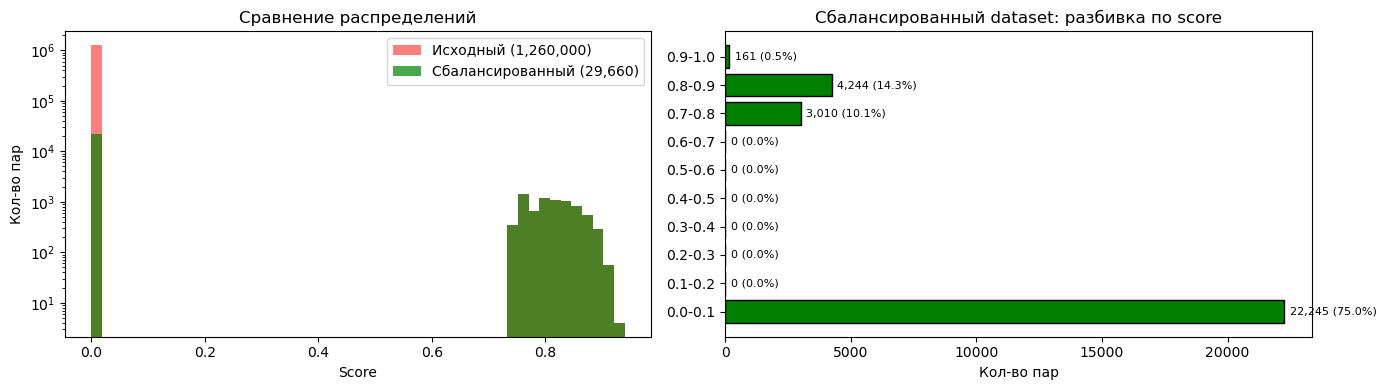

Сбалансированный dataset:
  Всего: 29,660
  Mean: 0.2029, Median: 0.0000
  Score = 0: 22,245 (75.0%)
  Score > 0: 7,415 (25.0%)


In [28]:
balanced_scores = np.array(balanced["score"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Сравнение распределений
axes[0].hist(scores, bins=50, alpha=0.5, label=f"Исходный ({len(scores):,})", color="red")
axes[0].hist(balanced_scores, bins=50, alpha=0.7, label=f"Сбалансированный ({len(balanced_scores):,})", color="green")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Кол-во пар")
axes[0].set_title("Сравнение распределений")
axes[0].set_yscale("log")
axes[0].legend()

# Сбалансированное распределение
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01]
counts, _ = np.histogram(balanced_scores, bins=bins)
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]
axes[1].barh(labels, counts, color="green", edgecolor="black")
axes[1].set_xlabel("Кол-во пар")
axes[1].set_title("Сбалансированный dataset: разбивка по score")
for i, c in enumerate(counts):
    axes[1].text(c + max(counts)*0.01, i, f"{c:,} ({c/len(balanced_scores)*100:.1f}%)", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Сбалансированный dataset:")
print(f"  Всего: {len(balanced_scores):,}")
print(f"  Mean: {balanced_scores.mean():.4f}, Median: {np.median(balanced_scores):.4f}")
print(f"  Score = 0: {(balanced_scores == 0).sum():,} ({(balanced_scores == 0).mean()*100:.1f}%)")
print(f"  Score > 0: {(balanced_scores > 0).sum():,} ({(balanced_scores > 0).mean()*100:.1f}%)")

## 5. Сохранение

In [29]:
balanced.to_parquet(OUTPUT_PARQUET)

file_size_mb = os.path.getsize(OUTPUT_PARQUET) / (1024 * 1024)
print(f"Сохранено: {OUTPUT_PARQUET}")
print(f"Размер: {file_size_mb:.1f} MB")
print(f"Пар: {len(balanced):,}")

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Сохранено: data/silver/silver_balanced.parquet
Размер: 23.9 MB
Пар: 29,660


## 6. Объединение с Golden Data (Augmented SBERT, Section 3.1)

Статья Thakur et al. (2021) требует объединить silver dataset с gold **train** split перед обучением bi-encoder:

> "The silver dataset [...] will be merged with the gold training dataset."

Схема:
1. Golden data → split 80/20 → **gold_train** + **gold_eval**
2. **gold_train** + **silver_balanced** → `train_gold_silver.parquet` (обучение bi-encoder)
3. **gold_eval** → `golden_eval.parquet` (оценка bi-encoder)

Это ключевое отличие от предыдущей версии, где bi-encoder обучался **только** на silver data.

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split

# --- 6.1. Загрузка golden data ---
gold_df = pd.read_csv(GOLDEN_DATA, sep="\t", encoding="utf-8-sig")
print(f"Golden data: {len(gold_df):,} пар")
print(f"Колонки: {list(gold_df.columns)}")

# Оставляем только нужные колонки и приводим к единому формату
gold_df = gold_df[["description", "post_text", "score"]].copy()
gold_df["score"] = gold_df["score"].astype(float)

# Переименуем description → product_desc для единообразия с silver
gold_df = gold_df.rename(columns={"description": "product_desc"})

# --- 6.2. Split gold → train / eval ---
gold_train, gold_eval = train_test_split(
    gold_df, test_size=GOLD_TEST_SIZE, random_state=GOLD_SEED, shuffle=True
)

print(f"\nGold train: {len(gold_train):,} пар (→ объединяется с silver)")
print(f"Gold eval:  {len(gold_eval):,} пар (→ оценка bi-encoder)")
print(f"  Train score mean: {gold_train['score'].mean():.4f}")
print(f"  Eval  score mean: {gold_eval['score'].mean():.4f}")

Golden data: 7,986 пар
Колонки: ['description', 'post_text', 'score', 'relevance_label', 'channel', 'post_id', 'link', 'date', 'views', 'category']

Gold train: 6,388 пар (→ объединяется с silver)
Gold eval:  1,598 пар (→ оценка bi-encoder)
  Train score mean: 0.3200
  Eval  score mean: 0.3362


In [31]:
# --- 6.3. Объединение gold_train + silver_balanced ---
silver_df = pd.read_parquet(OUTPUT_PARQUET)

merged = pd.concat([gold_train, silver_df], ignore_index=True)
merged = merged.sample(frac=1, random_state=SEED).reset_index(drop=True)  # перемешиваем

print(f"Silver balanced: {len(silver_df):,} пар")
print(f"Gold train:      {len(gold_train):,} пар")
print(f"Merged (train):  {len(merged):,} пар")
print(f"  Доля gold в train: {len(gold_train)/len(merged)*100:.1f}%")

# Статистика по score
print(f"\nMerged score stats:")
print(f"  Mean:  {merged['score'].mean():.4f}")
print(f"  Score = 0: {(merged['score'] == 0).sum():,} ({(merged['score'] == 0).mean()*100:.1f}%)")
print(f"  Score > 0: {(merged['score'] > 0).sum():,} ({(merged['score'] > 0).mean()*100:.1f}%)")

Silver balanced: 29,660 пар
Gold train:      6,388 пар
Merged (train):  36,048 пар
  Доля gold в train: 17.7%

Merged score stats:
  Mean:  0.2236
  Score = 0: 24,627 (68.3%)
  Score > 0: 11,421 (31.7%)


In [32]:
# --- 6.4. Сохранение ---
os.makedirs(os.path.dirname(OUTPUT_TRAIN_MERGED), exist_ok=True)

merged.to_parquet(OUTPUT_TRAIN_MERGED, index=False)
gold_eval.to_parquet(OUTPUT_GOLD_EVAL, index=False)

merged_size = os.path.getsize(OUTPUT_TRAIN_MERGED) / (1024 * 1024)
eval_size = os.path.getsize(OUTPUT_GOLD_EVAL) / (1024 * 1024)

print(f"Сохранено:")
print(f"  {OUTPUT_TRAIN_MERGED}: {len(merged):,} пар ({merged_size:.1f} MB)")
print(f"  {OUTPUT_GOLD_EVAL}: {len(gold_eval):,} пар ({eval_size:.1f} MB)")
print(f"\nТеперь bi-encoder.ipynb должен использовать:")
print(f"  Train: {OUTPUT_TRAIN_MERGED}")
print(f"  Eval:  {OUTPUT_GOLD_EVAL}")

Сохранено:
  data/silver/train_gold_silver.parquet: 36,048 пар (27.8 MB)
  data/golden/golden_eval.parquet: 1,598 пар (0.8 MB)

Теперь bi-encoder.ipynb должен использовать:
  Train: data/silver/train_gold_silver.parquet
  Eval:  data/golden/golden_eval.parquet
